**Zomato Dataset Analysis**

In [ ]:
!pip install pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

# Load data
df = pd.read_csv("/content/sample_data/zomato.csv")
df.head()


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


**Checking for missing values**

In [ ]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


**Missing values and  their counts**

In [ ]:
#  Check for missing values and counts
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Columns with missing values and their counts:")
    print(missing_values)
else:
    print("No missing values found in column.")


Columns with missing values and their counts:
address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64


**Checking duplicate rows or not ?**

In [ ]:
# Check for duplicate rows
print("Total number of rows:", len(df))
print("Number of duplicate rows:", df.duplicated().sum())
# Show duplicate rows (if any)
if df.duplicated().sum() > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=['name', 'address']).head(10))
else:
    print("\n✅ No duplicate rows found!")

Total number of rows: 56252
Number of duplicate rows: 15703

Sample of duplicate rows:
             address                                               name  \
49395   ('Rated 5.0'   ""RATED\n  A must-go place for delicious dess...   
49396   ('Rated 5.0'   ""RATED\n  A must-go place for delicious dess...   
49397   ('Rated 5.0'   ""RATED\n  A must-go place for delicious dess...   
49398   ('Rated 5.0'   ""RATED\n  A must-go place for delicious dess...   
40591   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   
40592   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   
40593   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   
40594   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   
40595   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   
41092   ('Rated 4.0'   ""RATED\n  A place which every bong loves to ...   

                                            online_order  \
49395   they had more staff

**Cleaning Duplicate Rows**

In [ ]:
# Remove exact duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("✅ Duplicate cleaning completed!")

Shape after removing duplicates: (40549, 13)
✅ Duplicate cleaning completed!


**Handle text fields**

In [ ]:
# Create a clean text function
def clean_text(text):
    if pd.isna(text):           # Handle missing values
        return ""
    text = str(text)
    # Remove special characters, keep only letters, numbers and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Cleaning to all important text columns
text_columns = ['name', 'address', 'cuisines', 'location',
                'rest_type', 'listed_in(type)', 'dish_liked']

for col in text_columns:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        df[col] = df[col].apply(clean_text)

# Create new features from text
df['cuisine_count'] = df['cuisines'].str.count(' ') + 1

# Popular cuisine flags
df['has_north_indian'] = df['cuisines'].str.contains('north indian', na=False).astype(int)
df['has_chinese'] = df['cuisines'].str.contains('chinese', na=False).astype(int)
df['has_south_indian'] = df['cuisines'].str.contains('south indian', na=False).astype(int)

print("✅ Text fields cleaning completed!")

Cleaning column: name
Cleaning column: address
Cleaning column: cuisines
Cleaning column: location
Cleaning column: rest_type
Cleaning column: listed_in(type)
Cleaning column: dish_liked
✅ Text fields cleaning completed!


In [ ]:
# Check result
print(df[['name', 'cuisines', 'location', 'listed_in(type)']].head(10))

                                                name  \
0                                              jalsa   
1                                     spice elephant   
2                                    san churro cafe   
3                              addhuri udupi bhojana   
4                                      grand village   
5                                    timepass dinner   
6        rosewood international hotel bar restaurant   
7                                             onesta   
8                                     penthouse cafe   
9  service was sluggish as they took too long to ...   

                                            cuisines  \
0                       north indian mughlai chinese   
1                          chinese north indian thai   
2                               cafe mexican italian   
3                          south indian north indian   
4                            north indian rajasthani   
5                                       north i

**Currency Conversions If Needed**

Zomato Bangalore dataset, all prices are in Indian Rupees (₹).So we don't need complex currency mapping — just clean the cost column and convert to USD.

In [ ]:
# 1. Clean the cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)\
    .str.replace(',', '', regex=False)          # Remove commas like 1,200 → 1200
# Convert to numeric
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'],
                                                   errors='coerce')
# Drop rows where cost is missing or invalid
df = df.dropna(subset=['approx_cost(for two people)'])
# 2. Currency Conversion (INR to USD)
INR_TO_USD_RATE = 0.011   #  update if needed

df['Cost_USD'] = df['approx_cost(for two people)'] * INR_TO_USD_RATE
df['Cost_USD'] = df['Cost_USD'].round(2)   # Round to 2 decimal places
# 3. Create Price Categories
df['price_range'] = pd.cut(df['approx_cost(for two people)'],
                           bins=[0, 300, 600, 1000, 1500, 3000, float('inf')],
                           labels=['Budget (<₹300)', 'Mid-Low (₹300-600)', 'Mid (₹600-1000)',
                                   'Mid-High (₹1000-1500)', 'Expensive (₹1500-3000)', 'Premium (>₹3000)'])

print("✅ Currency conversion completed!")
print("\nSample of Cost Columns:")
print(df[['approx_cost(for two people)', 'Cost_USD', 'price_range']].head(10))

print("\nPrice Range Distribution:")
print(df['price_range'].value_counts())

✅ Currency conversion completed!

Sample of Cost Columns:
    approx_cost(for two people)  Cost_USD         price_range
0                         800.0      8.80     Mid (₹600-1000)
1                         800.0      8.80     Mid (₹600-1000)
2                         800.0      8.80     Mid (₹600-1000)
3                         300.0      3.30      Budget (<₹300)
4                         600.0      6.60  Mid-Low (₹300-600)
5                         600.0      6.60  Mid-Low (₹300-600)
6                         800.0      8.80     Mid (₹600-1000)
7                         600.0      6.60  Mid-Low (₹300-600)
8                         700.0      7.70     Mid (₹600-1000)
10                        550.0      6.05  Mid-Low (₹300-600)

Price Range Distribution:
price_range
Mid-Low (₹300-600)        13841
Budget (<₹300)            12017
Mid (₹600-1000)            6309
Mid-High (₹1000-1500)      2698
Expensive (₹1500-3000)     1255
Premium (>₹3000)             63
Name: count, dtype: int64


**Exploring  relationships:**

1.Cuisine vs Rating

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_796/1023462724.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['rate'] = df['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)


🔥 Top 15 Cuisines by Average Rating:
                                           cuisines  average_rating  \
484                      cafe american burger steak        4.593333   
1825  north indian european mediterranean bbq kebab        4.492105   
1370                                  italian salad        4.415152   
2037                             pizza cafe italian        4.411765   
1541                                  modern indian        4.389796   
553                         cafe continental burger        4.259459   
1374                                       japanese        4.236111   
628              cafe italian burger american steak        4.168293   
566                 cafe continental italian burger        4.161224   
1322                                        italian        4.157143   
590                                   cafe desserts        4.111340   
1923      north indian mughlai south indian chinese        4.106000   
1043                             dessert

/tmp/ipykernel_796/1023462724.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cuisines.head(15),


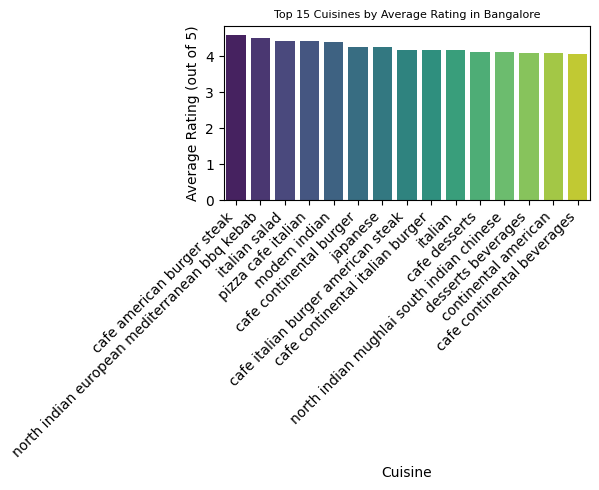

In [ ]:
# Clean Rating Column
df['rate'] = df['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)
# Clean Cuisines Column
df['cuisines'] = df['cuisines'].astype(str).str.lower().str.strip()
# Drop rows with missing rating or cuisines
df_clean = df.dropna(subset=['rate', 'cuisines'])
# Explode cuisines
cuisine_df = df_clean.assign(cuisines=df_clean['cuisines'].str.split(',')).explode('cuisines')
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.strip()
# Group by cuisine
cuisine_stats = cuisine_df.groupby('cuisines').agg(
    average_rating=('rate', 'mean'),
    number_of_restaurants=('rate', 'count'),
    total_votes=('votes', 'sum')
).reset_index()
# Filter cuisines with sufficient data
cuisine_stats = cuisine_stats[cuisine_stats['number_of_restaurants'] >= 30]
# Sort by rating
top_cuisines = cuisine_stats.sort_values('average_rating', ascending=False)

print("🔥 Top 15 Cuisines by Average Rating:")
print(top_cuisines.head(15)[['cuisines', 'average_rating', 'number_of_restaurants']])

# Top 15 Cuisines by Average Rating
plt.figure(figsize=(6, 5))

sns.barplot(data=top_cuisines.head(15),
            x='cuisines',
            y='average_rating',
            palette='viridis')

plt.title('Top 15 Cuisines by Average Rating in Bangalore', fontsize=8)
plt.xlabel('Cuisine')
plt.ylabel('Average Rating (out of 5)')
plt.xticks(rotation=45, ha='right')   # Rotate x labels for better readability
plt.tight_layout()
plt.show()

 Cuisines get the highest ratings in Bangalore.

Key Findings:

*   Singaporean, Modern Indian, Malaysian, Japanese, Mediterranean, and Sushi are at the top with very high average ratings (mostly 4.0+).

*   Premium and international cuisines tend to perform better than regular ones.

2. Location Hotspots

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_796/1907436687.py:6: SyntaxWarning: invalid escape sequence '\d'
  df_clean['rate'] = df_clean['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)
/tmp/ipykernel_796/1907436687.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['rate'] = df_clean['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)


🔥 Top 15 Location Hotspots in Bangalore (by number of restaurants):
                 location  num_restaurants  avg_rating
9                     btm             2434    3.606779
43  koramangala 5th block             1587    4.040265
25                    hsr             1553    3.694462
26            indiranagar             1544    3.831218
88             whitefield             1478    3.604736
54           marathahalli             1346    3.531055
32               jp nagar             1216    3.722944
30              jayanagar             1185    3.808776
5               bellandur              942    3.526327
2       bannerghatta road              907    3.533297
19        electronic city              812    3.490640
75          sarjapur road              763    3.654522
45  koramangala 7th block              700    3.907714
44  koramangala 6th block              672    3.828720
7            brigade road              658    3.744681


/tmp/ipykernel_796/1907436687.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hotspots.head(15),


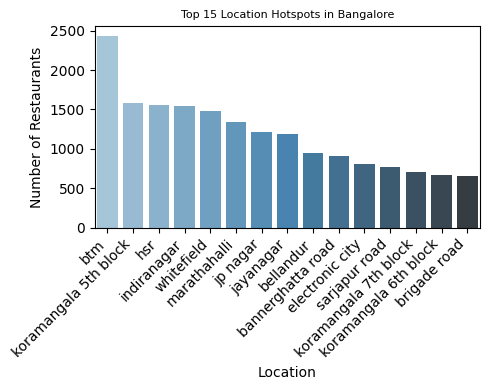

In [ ]:
# Clean location column
df['location'] = df['location'].astype(str).str.lower().str.strip()
# Drop rows with missing rating or location
df_clean = df.dropna(subset=['rate', 'location'])
# Clean rating
df_clean['rate'] = df_clean['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)
# Top Location Hotspots by Number of Restaurants
location_stats = df_clean.groupby('location').agg(
    num_restaurants=('rate', 'count'),
    avg_rating=('rate', 'mean'),
    total_votes=('votes', 'sum')
).reset_index()
# Top 15 locations by number of restaurants
top_hotspots = location_stats.sort_values('num_restaurants', ascending=False).head(15)

print("🔥 Top 15 Location Hotspots in Bangalore (by number of restaurants):")
print(top_hotspots[['location', 'num_restaurants', 'avg_rating']])

# Top 15 location  hotspot
plt.figure(figsize=(5, 4))

sns.barplot(data=top_hotspots.head(15),
            x='location',
            y='num_restaurants',
            palette='Blues_d')

plt.title('Top 15 Location Hotspots in Bangalore', fontsize=8)
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Areas in Bangalore have the most restaurants.

Key Findings:

*  BTM is the biggest hotspot (highest number of restaurants).

*   Koramangala (5th block, 6th block, 7th block) dominates the list.

*   Other busy areas: Indiranagar, JP Nagar, Jayanagar, Whitefield.

Price vs Rating

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_796/1629279156.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['rate'] = df['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)
/tmp/ipykernel_796/1629279156.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['price_range'] = pd.cut(df_clean['approx_cost(for two people)'],
/tmp/ipykernel_796/1629279156.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = df_clean.groupby('price_range').agg(
/tmp/ipykernel

Data after cleaning: (30703, 19)

💰 Price Range vs Average Rating:
              price_range  average_rating  num_restaurants  avg_votes
0          Budget (<₹300)            3.58             8818      80.07
1      Mid-Low (₹300-600)            3.62            11957     220.20
2         Mid (₹600-1000)            3.82             5998     526.57
3   Mid-High (₹1000-1500)            4.11             2630    1154.37
4  Expensive (₹1500-3000)            4.17             1237    1318.42
5        Premium (>₹3000)            4.26               63     402.29


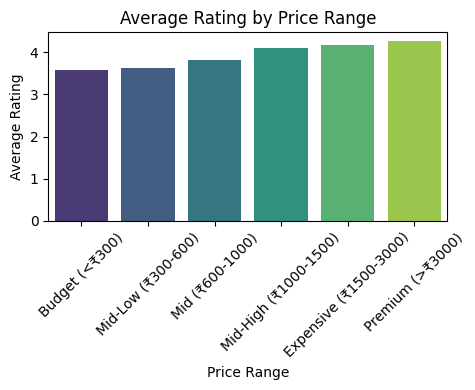

In [ ]:
# Safe Cleaning for Rate and Cost
df['rate'] = df['rate'].astype(str).str.extract('(\d+\.\d+)').astype(float)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
# Clean 'votes' column and convert to numeric
df['votes'] = df['votes'].astype(str).str.replace(',', '', regex=False) # Remove commas if any
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
# Drop rows with missing values
df_clean = df.dropna(subset=['rate', 'approx_cost(for two people)', 'votes']) # Add 'votes' to subset for dropna
print("Data after cleaning:", df_clean.shape)
# Create Price Range Categories
df_clean['price_range'] = pd.cut(df_clean['approx_cost(for two people)'],
                                 bins=[0, 300, 600, 1000, 1500, 3000, float('inf')],
                                 labels=['Budget (<₹300)', 'Mid-Low (₹300-600)', 'Mid (₹600-1000)',
                                         'Mid-High (₹1000-1500)', 'Expensive (₹1500-3000)', 'Premium (>₹3000)'])
#  analysis
price_rating = df_clean.groupby('price_range').agg(
    average_rating=('rate', 'mean'),
    num_restaurants=('rate', 'count'),
    avg_votes=('votes', 'mean')
).reset_index()

print("\n💰 Price Range vs Average Rating:")
print(price_rating.round(2))

#  Bar Plot: Average Rating by Price Range
plt.figure(figsize=(5, 4))
sns.barplot(data=price_rating, x='price_range', y='average_rating', palette='viridis')
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Restaurant ratings change with price (cost for two people).

Key Findings:

*   Premium restaurants (> ₹3000) have the highest average rating (~4.23).
*   Ratings gradually increase as price increases.

*   Budget restaurants (< ₹300) have the lowest average ratings.


Generally, higher priced restaurants get better ratings, but mid-range restaurants offer the best balance of rating and volume.

**Building  Visualizations By  Heatmaps**

1. Correlation Heatmap

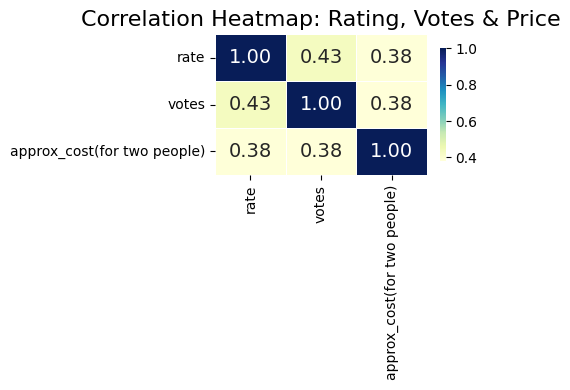

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(5, 4))
correlation = df[['rate', 'votes', 'approx_cost(for two people)']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='YlGnBu',        #  gives Yellow → Light Blue → Dark Blue
            linewidths=0.5,
            fmt='.2f',
            annot_kws={"size": 14},
            cbar_kws={"shrink": 0.8})
#plot
plt.title('Correlation Heatmap: Rating, Votes & Price', fontsize=16)
plt.tight_layout()
plt.show()

Key Insight from this Heatmap:


*  Votes (Number of Reviews) is the strongest factor related to high ratings (0.43).

*  Price has some positive effect on rating, but it's not very strong.

*  Overall, more popular restaurants (high votes) usually get higher ratings.

**Build visualizations: wordclouds for reviews or popular cuisines**

1. WordCloud for Popular Cuisines

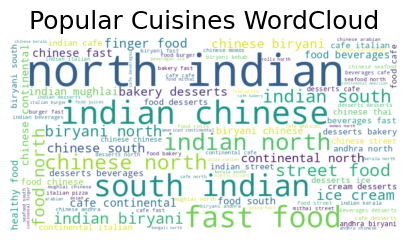

In [ ]:
# Clean cuisines
df['cuisines'] = df['cuisines'].astype(str).str.lower().str.strip()
# Combine all cuisines into one big text
all_cuisines = ' '.join(df['cuisines'].dropna())
# Generate WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_cuisines)

# Plot
plt.figure(figsize=(5, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Popular Cuisines WordCloud', fontsize=18)
plt.show()

The most frequently appearing cuisines in the dataset.

Key Findings:


*   North Indian, Chinese, Indian, South Indian, Fast Food are the most common.

*   Other frequent words: Biryani, Continental, Bakery, Desserts, Street Food.



These are the most available cuisines in Bangalore, even if they don’t always get the highest ratings.

**Top 10 Cuisines Table **

In [ ]:
# Top 10 Cuisines
top_cuisines = df['cuisines'].str.split(',').explode().str.strip().value_counts().head(10)
print("Top 10 Popular Cuisines:")
print(top_cuisines)

Top 10 Popular Cuisines:
cuisines
north indian                         2025
north indian chinese                 1694
south indian                         1216
bakery desserts                       634
biryani                               604
fast food                             528
south indian north indian chinese     507
cafe                                  482
desserts                              481
bakery                                413
Name: count, dtype: int64


** Recommendations for Alfido Tech style platform **

1. Focus on Mid-Range Restaurants in Top Hotspots

* Insight: Mid-priced restaurants (₹600–₹1000 for two) consistentlyget
  good ratings and high volume.

* Recommendation:  

* Prioritize partnering with Mid-range restaurants in Koramangala,  Indiranagar, BTM, and Jayanagar.

* Offer special deals or featured listings for restaurants in these areas and price segments.

* Create a filter called “Best Value” that highlights good-rated restaurants under ₹1000.

2. Premium Cuisine Partnerships

* Insight: Cuisines like Italian, Continental, Japanese, Asian, and Thai get higher average ratings.

* Recommendation:

* Partner with restaurants serving premium/multi-cuisines (especially in Koramangala & Whitefield).

* Launch a “Premium Picks” or “Fine Dining Under ₹1500” campaign.

* Give these restaurants priority in recommendations and marketing.

3. Content Ideas – “Bangalore Food Guides”

 Create engaging content to attract users:

* “Top 10 Must-Try Cuisines in Bangalore” (with wordcloud visuals)

* “Best Restaurants by Budget” – Budget, Mid, Premium guides

* “Best Places for Table Booking” (restaurants with high book_table)

* “Late Night Delivery Options” (useful for Bangalore’s IT crowd)